# 23 — Gateway IG Validation (Camargo Helpdesk)

For every qualifying gateway (decision point with at least 2 well-populated
successors), this notebook compares three feature-importance signals:

1. **IG (LSTM attention)** — Integrated Gradients on the Camargo single-step
   model, aggregated as `|attribution|.sum()` per input feature.
2. **LSTM-surrogate decision tree (Gini)** — C4.5 tree fit on the LSTM's
   predicted next activity (fidelity tree).
3. **Ground-truth decision tree (Gini)** — C4.5 tree fit on the actual next
   activity. Same prefixes, same train/val/test split.

The single-panel 3-bar chart per gateway shows the three signals normalized
against their own maxima, with Spearman rank correlations IG-vs-GT and
IG-vs-Surrogate in the title.

EOS-target prefixes (case-end transitions) are included via
`iter_case_prefixes(..., include_end=True)`, so gateways with EOS as a
successor (e.g. `Closed -> EOS`) are first-class.


## Setup

In [ ]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

from src.interpretability.surrogate.c45_tree import C45Classifier

SPEC = utils.HELPDESK_SHAREDCAT_ROLES_NGRAM
model = utils.load_camargo_model(_current, SPEC)
dataset = utils.load_test_dataset(_current, SPEC)
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)

ACT_IDX, RES_IDX = SPEC.cat_indices
CET_IDX = SPEC.num_indices[0]
idx_to_name = predictor.idx_to_name
eos_idx = predictor.eos_idx
# Resource/Role label vocab so categorical positional features stay categorical
# in the surrogate trees (don't let C4.5 split a Role on '> 2.5').
res_idx_to_name = {v: k for k, v in model.data_set_categories[0][1][2].items()}

# The three input features the Camargo model sees, ordered as in compute_integrated_gradients
FEATURE_NAMES = ['Activity', 'Resource', 'case_elapsed_time']

print(f'Model: {SPEC.name} | window={window} | vocab={predictor.n_classes} classes | |test|={len(dataset)}')


## Identify gateways and collect prefixes

In [2]:
# Hyperparameters mirror notebook 22 so the surrogate + GT trees fit here
# are identical to those in 22_gateway_decision_analysis.
MIN_CASES = 4
MIN_BRANCH = 1
MIN_SAMPLES_LEAF = 20
ACTIVITY_WINDOW = 10
IG_STEPS = 30
MAX_SAMPLES_PER_GATEWAY = 100   # cap IG samples per gateway

# Unique cases (longest trace per case_id)
cases = {}
for i in range(len(dataset)):
    cat_t, _, cid = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if cid not in cases or trace_len > cases[cid][1]:
        cases[cid] = (i, trace_len)

# DFG with synthetic EOS at the case end
dfg = {}
for case_id, (ds_idx, _) in cases.items():
    cat_full = dataset[ds_idx][0]
    acts = cat_full[ACT_IDX].tolist()
    nonzero = [i for i, a in enumerate(acts) if a != 0]
    if not nonzero:
        continue
    start = nonzero[0]
    useful_len = len(nonzero)
    while useful_len > 0 and acts[start + useful_len - 1] == eos_idx:
        useful_len -= 1
    names = [idx_to_name.get(acts[start + k]) for k in range(useful_len)] + ['EOS']
    for k in range(len(names) - 1):
        edge = (names[k], names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

successors_map = {}
for (src, tgt), c in dfg.items():
    successors_map.setdefault(src, {})[tgt] = c
decision_points = {a: s for a, s in successors_map.items() if len(s) > 1}
print(f'{len(decision_points)} decision points')


9 decision points


In [ ]:
def extract_features(acts_history, res_history, cet_history, prefix_len):
    feats = {'prefix_length': prefix_len}
    for w in range(1, ACTIVITY_WINDOW + 1):
        pos = prefix_len - w
        feats[f'activity_pos_{-w}'] = idx_to_name.get(acts_history[pos]) if pos >= 0 else '<pad>'
        feats[f'resource_pos_{-w}'] = res_idx_to_name.get(int(res_history[pos]), str(int(res_history[pos]))) if pos >= 0 else '<pad>'
        feats[f'cet_pos_{-w}'] = float(cet_history[pos]) if pos >= 0 else float('nan')
    return feats


gateway_data = {}
skipped = []
for gateway_act, succs in decision_points.items():
    qualifying = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying) < 2 or sum(succs.values()) < MIN_CASES:
        skipped.append((gateway_act, dict(succs)))
        continue

    rows_X, y_actual, y_lstm = [], [], []
    win_cats_list, win_nums_list, target_list = [], [], []
    for case_id, (ds_idx, _) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        acts_raw = cat_full[ACT_IDX].tolist()
        nonzero = [i for i, a in enumerate(acts_raw) if a != 0]
        if not nonzero:
            continue
        start = nonzero[0]
        useful_len = len(nonzero)
        while useful_len > 0 and acts_raw[start + useful_len - 1] == eos_idx:
            useful_len -= 1

        for k in range(useful_len):
            if idx_to_name.get(acts_raw[start + k]) != gateway_act:
                continue
            prefix_len = k + 1
            if k < useful_len - 1:
                next_name = idx_to_name.get(acts_raw[start + prefix_len])
            else:
                next_name = 'EOS'

            cats_win, nums_win = utils.make_prefix_window(
                cat_full, num_full, start=start, prefix_length=prefix_len,
                window=window, spec=SPEC,
            )
            pred_idx, _ = predictor.predict_batch(cats_win, nums_win)
            target = int(pred_idx.item())
            pred_name = idx_to_name.get(target, f'<{target}>')

            acts_history = [acts_raw[start + j] for j in range(prefix_len)]
            res_full = cat_full[RES_IDX].tolist()
            res_history = [res_full[start + j] for j in range(prefix_len)]
            cet_full = num_full[CET_IDX].tolist()
            cet_history = [cet_full[start + j] for j in range(prefix_len)]

            rows_X.append(extract_features(acts_history, res_history, cet_history, prefix_len))
            y_actual.append(next_name)
            y_lstm.append(pred_name)
            win_cats_list.append(cats_win)
            win_nums_list.append(nums_win)
            target_list.append(target)

    if len(rows_X) < MIN_CASES:
        skipped.append((gateway_act, f'collected {len(rows_X)} < MIN_CASES={MIN_CASES}'))
        continue

    X = pd.DataFrame(rows_X)
    y_actual = np.array(y_actual)
    y_lstm = np.array(y_lstm)
    lstm_acc = float((y_lstm == y_actual).mean())
    print(f'{gateway_act}: N={len(X)} | LSTM acc={lstm_acc:.3f} | actual={len(set(y_actual))} branches | LSTM={len(set(y_lstm))} branches')
    gateway_data[gateway_act] = {
        'X': X, 'y_actual': y_actual, 'y_lstm': y_lstm,
        'win_cats': win_cats_list, 'win_nums': win_nums_list, 'targets': target_list,
        'successors': succs,
    }

print(f'\n{len(gateway_data)} qualifying gateways')
if skipped:
    print(f'Skipped {len(skipped)} decision points (insufficient data)')


## Train surrogate + ground-truth trees

Same 60/20/20 stratified split for both trees so they're scored on identical
held-out prefixes. C4.5 with depth selection on the validation fold.

In [4]:
def select_depth(X_tr, y_tr, X_val, y_val, cat_feats, depths=(3, 4, 5, 6, 7, 8)):
    best = None
    for d in depths:
        clf = C45Classifier(max_depth=d, min_samples_leaf=MIN_SAMPLES_LEAF,
                            class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr, categorical_features=cat_feats)
        val = clf.score(X_val, y_val)
        if best is None or val > best['val'] + 0.02:
            best = {'depth': d, 'val': val, 'clf': clf}
    return best['clf']


gateway_results = {}
for gw, gd in gateway_data.items():
    X, y_actual, y_lstm = gd['X'], gd['y_actual'], gd['y_lstm']
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']

    try:
        X_tv, X_te, y_lstm_tv, y_lstm_te, y_act_tv, y_act_te = train_test_split(
            X, y_lstm, y_actual, test_size=0.2, random_state=42, stratify=y_actual)
    except ValueError:
        X_tv, X_te, y_lstm_tv, y_lstm_te, y_act_tv, y_act_te = train_test_split(
            X, y_lstm, y_actual, test_size=0.2, random_state=42)
    try:
        X_tr, X_val, y_lstm_tr, y_lstm_val, y_act_tr, y_act_val = train_test_split(
            X_tv, y_lstm_tv, y_act_tv, test_size=0.25, random_state=42, stratify=y_act_tv)
    except ValueError:
        X_tr, X_val, y_lstm_tr, y_lstm_val, y_act_tr, y_act_val = train_test_split(
            X_tv, y_lstm_tv, y_act_tv, test_size=0.25, random_state=42)

    clf_lstm = select_depth(X_tr, y_lstm_tr, X_val, y_lstm_val, cat_cols)
    clf_gt = select_depth(X_tr, y_act_tr, X_val, y_act_val, cat_cols)

    gateway_results[gw] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': list(X.columns),
        'fidelity': clf_lstm.score(X_te, y_lstm_te),
        'gt_acc': clf_gt.score(X_te, y_act_te),
        'lstm_acc': float((y_lstm_te == y_act_te).mean()),
        'cat_cols': cat_cols,
    }
    gr = gateway_results[gw]
    print(f'{gw}: fidelity={gr["fidelity"]:.3f} | GT acc={gr["gt_acc"]:.3f} | LSTM acc={gr["lstm_acc"]:.3f}')


Assign seriousness: fidelity=1.000 | GT acc=0.849 | LSTM acc=0.849
Take in charge ticket: fidelity=0.995 | GT acc=0.685 | LSTM acc=0.680
Resolve ticket: fidelity=0.975 | GT acc=0.924 | LSTM acc=0.929
Closed: fidelity=1.000 | GT acc=0.973 | LSTM acc=0.973
Wait: fidelity=0.737 | GT acc=0.579 | LSTM acc=0.632
Insert ticket: fidelity=1.000 | GT acc=1.000 | LSTM acc=1.000
Require upgrade: fidelity=1.000 | GT acc=0.400 | LSTM acc=0.400
Create SW anomaly: fidelity=0.667 | GT acc=0.333 | LSTM acc=0.333


## Compute IG attributions per gateway

Up to `MAX_SAMPLES_PER_GATEWAY` prefixes per gateway. For each prefix, runs IG
with the LSTM's predicted class as target and aggregates `|attribution|.sum()`
per Camargo input feature.

In [5]:
ig_results = {}
for gateway_act, gd in gateway_data.items():
    N = len(gd['X'])
    sample_idx = list(range(N))
    if N > MAX_SAMPLES_PER_GATEWAY:
        rng = np.random.RandomState(42)
        sample_idx = rng.choice(N, MAX_SAMPLES_PER_GATEWAY, replace=False).tolist()
    print(f'{gateway_act}: IG on {len(sample_idx)}/{N} prefixes')

    rows = []
    for idx in tqdm(sample_idx, desc=gateway_act, leave=False):
        cats_win = gd['win_cats'][idx]
        nums_win = gd['win_nums'][idx]
        target = gd['targets'][idx]
        try:
            cat_attrs, num_attrs = utils.compute_integrated_gradients(
                model, cats_win, nums_win, target_class=target, n_steps=IG_STEPS,
            )
        except Exception as e:
            print(f'  IG failed @ idx={idx}: {e}')
            continue

        attr = {}
        for i, name in enumerate(FEATURE_NAMES[:len(cat_attrs)]):
            attr[name] = float(cat_attrs[i].abs().sum().item())
        for j, name in enumerate(FEATURE_NAMES[len(cat_attrs):]):
            attr[name] = float(num_attrs[j].abs().sum().item())
        attr['y_lstm'] = gd['y_lstm'][idx]
        attr['y_actual'] = gd['y_actual'][idx]
        rows.append(attr)

    if rows:
        ig_results[gateway_act] = pd.DataFrame(rows)
        print(f'  {len(rows)} IG attributions computed')

print(f'\nIG results for {len(ig_results)} gateways')


Assign seriousness: IG on 100/995 prefixes


Assign seriousness:   0%|          | 0/100 [00:00<?, ?it/s]

  100 IG attributions computed
Take in charge ticket: IG on 100/996 prefixes


Take in charge ticket:   0%|          | 0/100 [00:00<?, ?it/s]

  100 IG attributions computed
Resolve ticket: IG on 100/988 prefixes


...

  28 IG attributions computed
Require upgrade: IG on 21/21 prefixes


Require upgrade:   0%|          | 0/21 [00:00<?, ?it/s]

  21 IG attributions computed
Create SW anomaly: IG on 12/12 prefixes


Create SW anomaly:   0%|          | 0/12 [00:00<?, ?it/s]

  12 IG attributions computed

IG results for 8 gateways


## IG vs Ground-Truth tree vs LSTM-Surrogate tree

For each gateway, normalized IG attribution (LSTM attention) plotted alongside
the Gini importances of the GT decision tree and the LSTM-surrogate tree.
Each Camargo input feature is mapped to its engineered counterparts in the
trees by taking the **max** Gini over all positional features for the same
underlying input (e.g. `Activity` aggregates `activity_pos_-1`,
`activity_pos_-2`, ..., `activity_pos_-W`).

/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


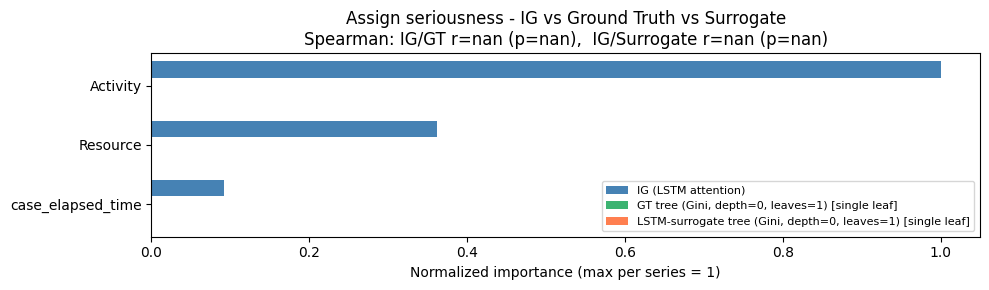


Assign seriousness - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,Activity,1.2250,0.0,0.0
1,Resource,0.4432,0.0,0.0
2,case_elapsed_time,0.1126,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


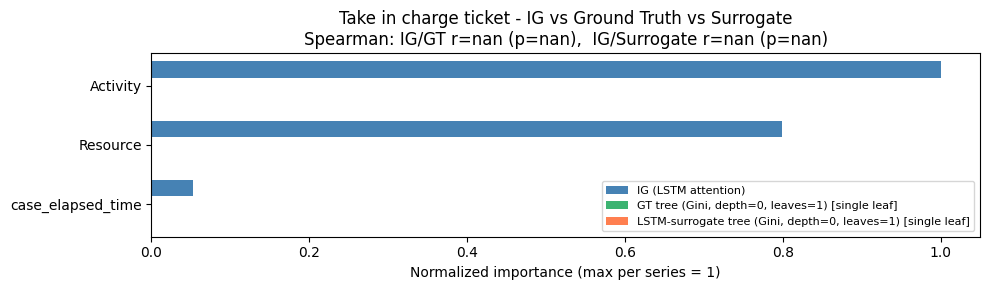


Take in charge ticket - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,Activity,0.8112,0.0,0.0
1,Resource,0.6488,0.0,0.0
2,case_elapsed_time,0.0424,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


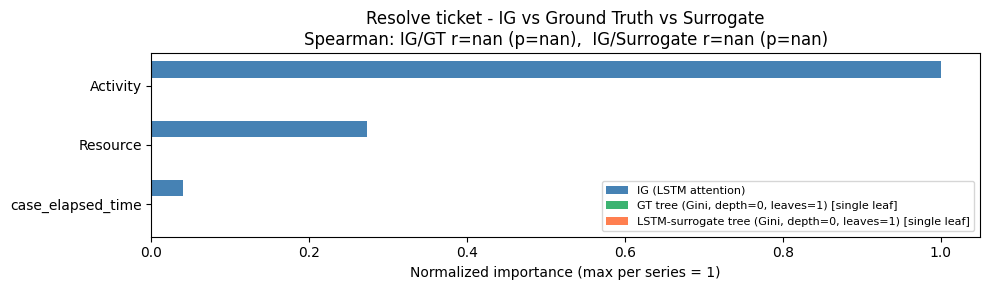


Resolve ticket - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,Activity,1.9390,0.0,0.0
1,Resource,0.5297,0.0,0.0
2,case_elapsed_time,0.0766,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


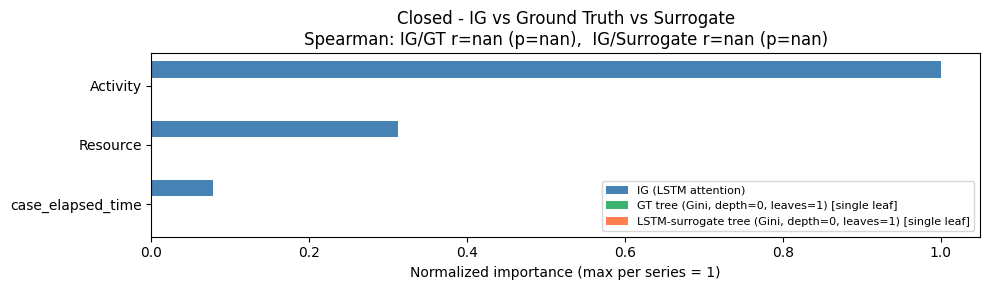


Closed - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,Activity,1.8001,0.0,0.0
1,Resource,0.5631,0.0,0.0
2,case_elapsed_time,0.1412,0.0,0.0


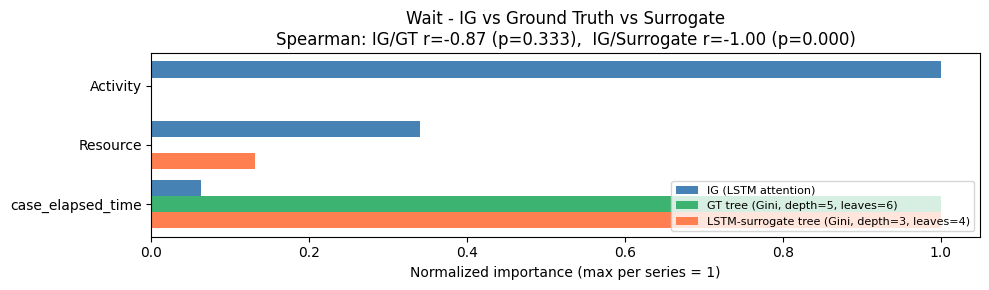


Wait - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,Activity,2.0562,0.0000,0.000
1,Resource,0.6995,0.0000,0.116
2,case_elapsed_time,0.1297,0.6357,0.884


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


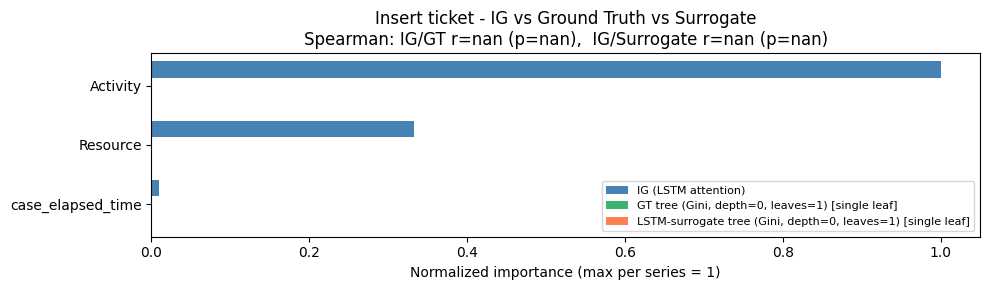


Insert ticket - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,Activity,1.0089,0.0,0.0
1,Resource,0.3361,0.0,0.0
2,case_elapsed_time,0.0103,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


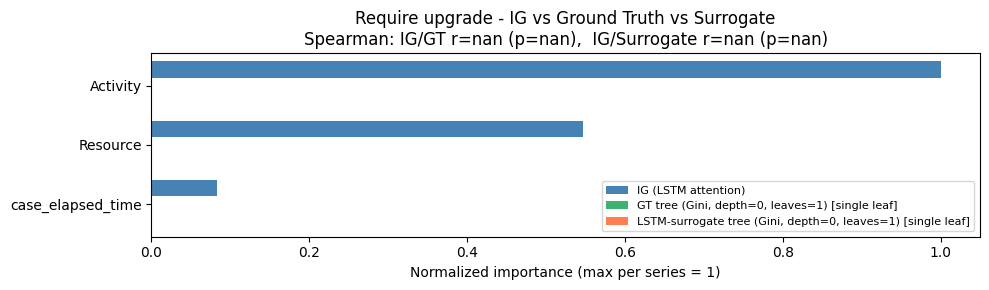


Require upgrade - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,Activity,1.0113,0.0,0.0
1,Resource,0.5527,0.0,0.0
2,case_elapsed_time,0.0837,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_94285/1319428692.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


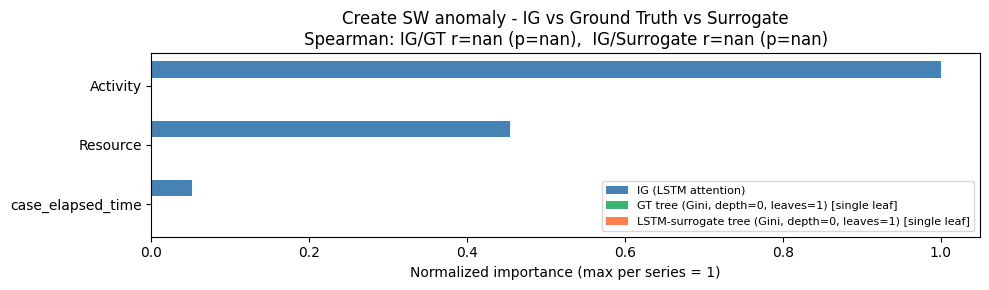


Create SW anomaly - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,Activity,1.6876,0.0,0.0
1,Resource,0.7666,0.0,0.0
2,case_elapsed_time,0.0863,0.0,0.0


In [6]:
def aggregate_engineered(model_feat, importances, feature_names):
    """Max importance over engineered features that share the same underlying
    Camargo input feature (positional history collapses to a single bar)."""
    if model_feat == 'Activity':
        keys = [f for f in feature_names if f.startswith('activity_pos_')]
    elif model_feat == 'Resource':
        keys = [f for f in feature_names if f.startswith('resource_pos_')]
    elif model_feat == 'case_elapsed_time':
        keys = [f for f in feature_names if f.startswith('cet_pos_')]
    else:
        keys = [model_feat] if model_feat in feature_names else []
    imp_dict = dict(zip(feature_names, importances))
    return max((imp_dict.get(k, 0.0) for k in keys), default=0.0)


for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    gr = gateway_results[gateway_act]

    available = [f for f in FEATURE_NAMES if f in ig_df.columns]
    ig_mean = ig_df[available].mean()

    fnames = gr['feature_names']
    surr_imp = gr['clf_lstm'].feature_importances_
    gt_imp = gr['clf_gt'].feature_importances_

    rows = []
    for feat in available:
        rows.append({
            'feature': feat,
            'ig_mean': float(ig_mean[feat]),
            'gt_gini': aggregate_engineered(feat, gt_imp, fnames),
            'surrogate_gini': aggregate_engineered(feat, surr_imp, fnames),
        })
    comp_df = pd.DataFrame(rows).sort_values('ig_mean', ascending=False)

    if len(comp_df) >= 2:
        rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
        rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])
    else:
        rho_gt = rho_surr = float('nan')
        p_gt = p_surr = float('nan')

    def safe_norm(arr):
        m = arr.max()
        return arr / m if m > 0 else arr

    ig_norm = safe_norm(comp_df['ig_mean'].values)
    gt_norm = safe_norm(comp_df['gt_gini'].values)
    surr_norm = safe_norm(comp_df['surrogate_gini'].values)

    gt_clf, surr_clf = gr['clf_gt'], gr['clf_lstm']
    gt_d, gt_l = gt_clf.get_depth(), gt_clf.get_n_leaves()
    surr_d, surr_l = surr_clf.get_depth(), surr_clf.get_n_leaves()
    gt_stub = ' [single leaf]' if gt_d == 0 else ''
    surr_stub = ' [single leaf]' if surr_d == 0 else ''

    fig, ax = plt.subplots(figsize=(10, max(3, len(comp_df) * 0.55)))
    y_pos = np.arange(len(comp_df))
    bar_h = 0.27

    ax.barh(y_pos - bar_h, ig_norm, bar_h, label='IG (LSTM attention)', color='steelblue')
    ax.barh(y_pos,         gt_norm, bar_h,
            label=f'GT tree (Gini, depth={gt_d}, leaves={gt_l}){gt_stub}',
            color='mediumseagreen')
    ax.barh(y_pos + bar_h, surr_norm, bar_h,
            label=f'LSTM-surrogate tree (Gini, depth={surr_d}, leaves={surr_l}){surr_stub}',
            color='coral')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(comp_df['feature'].values, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized importance (max per series = 1)')
    ax.set_title(
        f'{gateway_act} - IG vs Ground Truth vs Surrogate\n'
        f'Spearman: IG/GT r={rho_gt:.2f} (p={p_gt:.3f}),  '
        f'IG/Surrogate r={rho_surr:.2f} (p={p_surr:.3f})'
    )
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()

    print(f'\n{gateway_act} - Feature ranking comparison:')
    display(comp_df.round(4))


## IG attribution: correct vs incorrect predictions

When the LSTM mispredicts the gateway branch, which features did it
over- or under-weight relative to the correct cases?

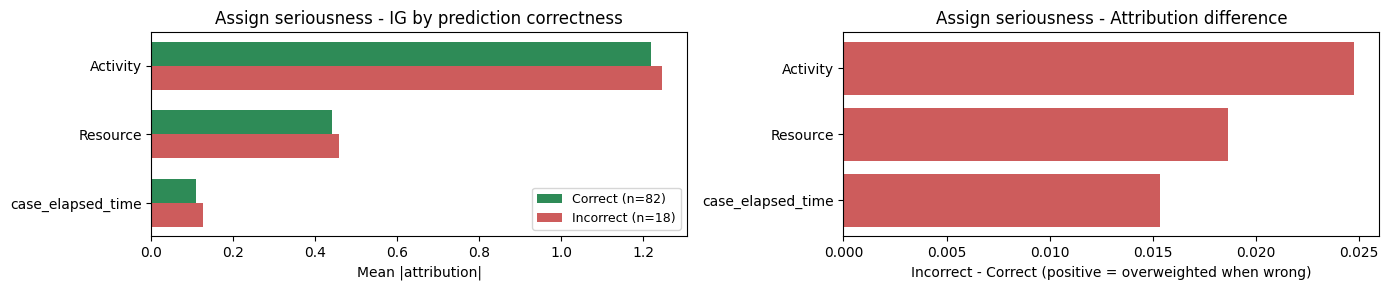

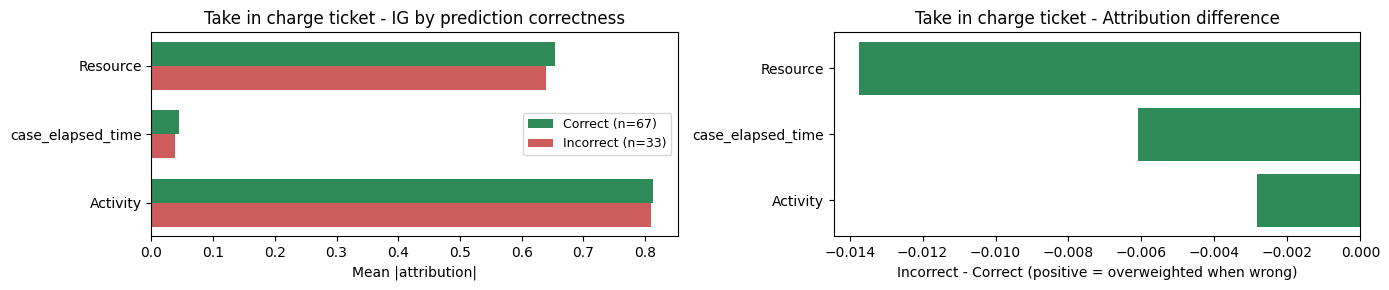

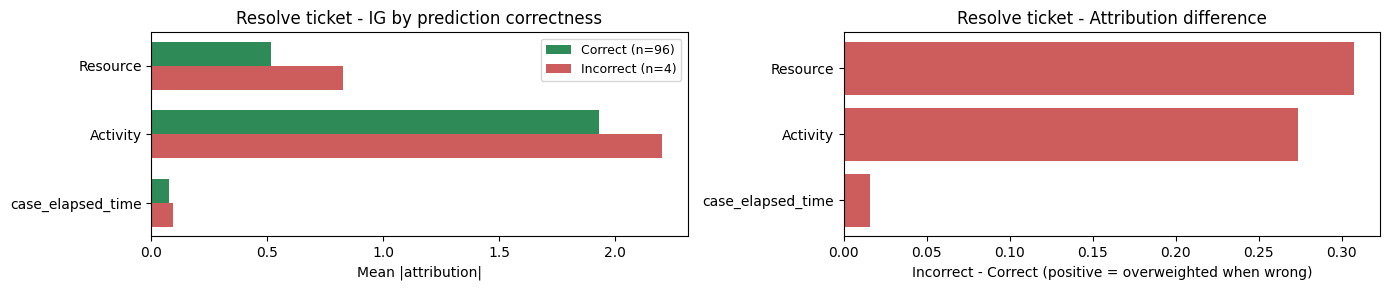

Closed: only 0 incorrect, skipping


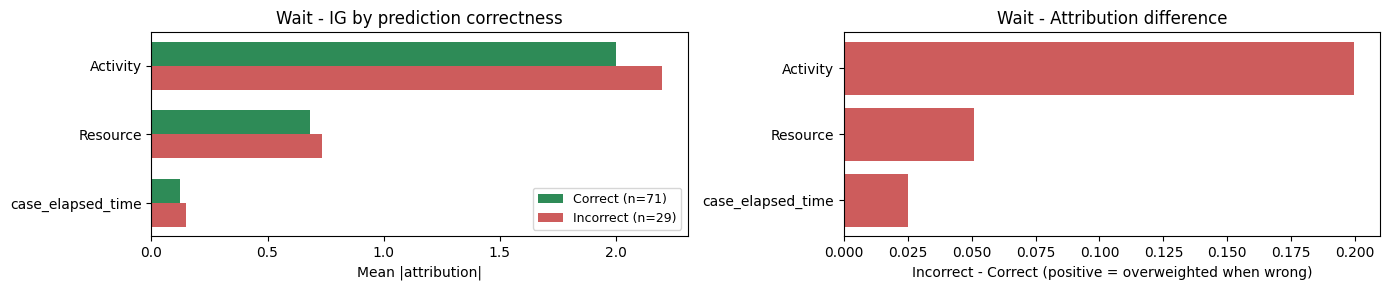

Insert ticket: only 2 incorrect, skipping


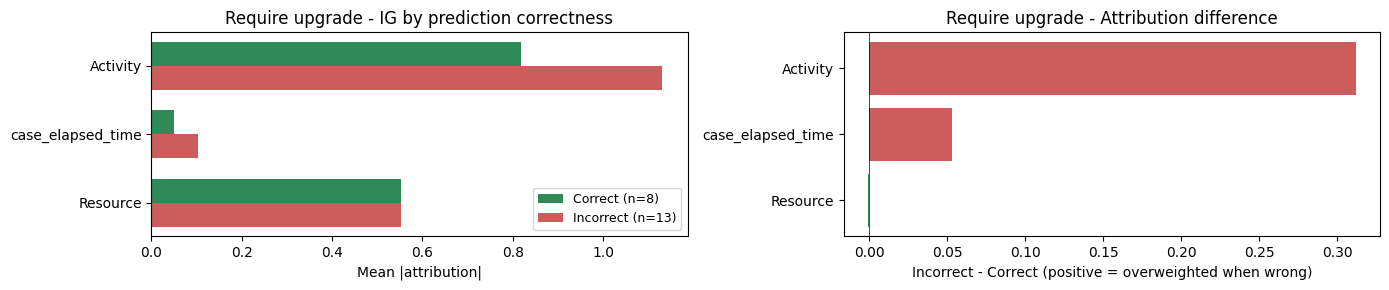

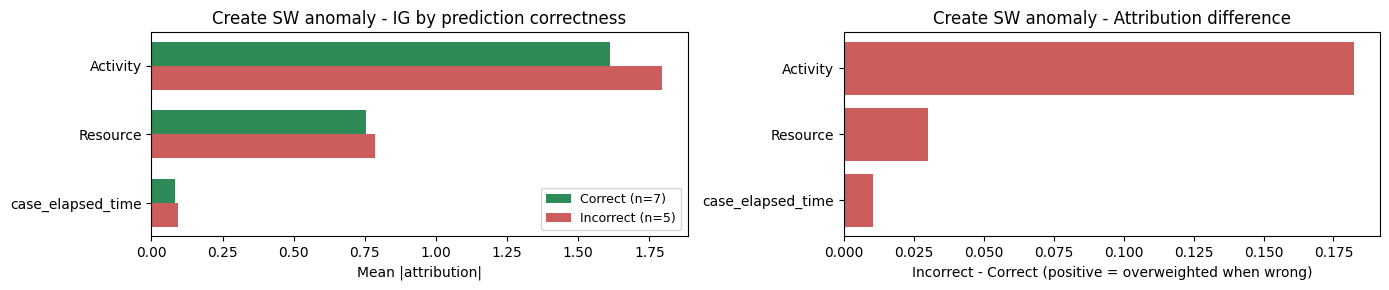

In [7]:
for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    available = [f for f in FEATURE_NAMES if f in ig_df.columns]

    correct = ig_df[ig_df['y_lstm'] == ig_df['y_actual']]
    incorrect = ig_df[ig_df['y_lstm'] != ig_df['y_actual']]
    if len(incorrect) < 3:
        print(f'{gateway_act}: only {len(incorrect)} incorrect, skipping')
        continue

    mc = correct[available].mean()
    mi = incorrect[available].mean()
    diff = mi - mc
    order = diff.abs().sort_values(ascending=False).index
    mc, mi, diff = mc[order], mi[order], diff[order]

    fig, axes = plt.subplots(1, 2, figsize=(14, max(3, len(available) * 0.55)))
    y_pos = np.arange(len(order))
    bar_h = 0.35

    ax = axes[0]
    ax.barh(y_pos - bar_h / 2, mc.values, bar_h, label=f'Correct (n={len(correct)})', color='seagreen')
    ax.barh(y_pos + bar_h / 2, mi.values, bar_h, label=f'Incorrect (n={len(incorrect)})', color='indianred')
    ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=10); ax.invert_yaxis()
    ax.set_xlabel('Mean |attribution|')
    ax.set_title(f'{gateway_act} - IG by prediction correctness')
    ax.legend(fontsize=9)

    ax = axes[1]
    colors = ['indianred' if d > 0 else 'seagreen' for d in diff.values]
    ax.barh(y_pos, diff.values, color=colors)
    ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=10); ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Incorrect - Correct (positive = overweighted when wrong)')
    ax.set_title(f'{gateway_act} - Attribution difference')
    plt.tight_layout()
    plt.show()
